# Polish Additions — Punjab Stubble-Burning Fire Project

Five lightweight enhancements on top of the completed modeling pipeline.
No model retraining (except one quick XGBoost for the counterfactual section).

| Addition | What it does |
|----------|-------------|
| 1 | CPCB PM2.5 station validation framework |
| 2 | Counterfactual policy scenario simulation |
| 3 | Moran's I spatial autocorrelation on residuals |
| 4 | Conformal prediction intervals (MAPIE) |
| 5 | Named Punjab district breakdown |


## Phase 0 — Setup

In [1]:
import os, sys, glob, warnings, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, average_precision_score

ORANGE = '#E8512A'; GREEN = '#27AE60'; NAVY = '#1F3A93'
GREY   = '#7F8C8D'; PURPLE = '#9B59B6'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 120

os.makedirs('outputs', exist_ok=True)
os.makedirs('figures', exist_ok=True)

import subprocess
for pkg in ['mapie', 'libpysal', 'esda']:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'  pip install {pkg}: {status}')

import xgboost as xgb
print('\nSetup OK')


  pip install mapie: OK


  pip install libpysal: OK


  pip install esda: OK

Setup OK


## Phase 1 — Load Master Data, Model, Predictions

In [2]:
# Verify required artifacts
required = {
    'punjab_features_master_clean.csv': 'Master feature table',
    'models/xgb_tuned_final.json':      'Tuned XGBoost model',
    'outputs/final_metrics.csv':        'Final test metrics',
    'outputs/ablation_results.csv':     'Ablation results',
    'outputs/shap_importance.csv':      'SHAP importance',
}
print('Artifact check:')
for path, desc in required.items():
    exists = os.path.exists(path)
    print(f'  {"✓" if exists else "✗"}  {path}  ({desc})')


Artifact check:
  ✓  punjab_features_master_clean.csv  (Master feature table)
  ✓  models/xgb_tuned_final.json  (Tuned XGBoost model)
  ✓  outputs/final_metrics.csv  (Final test metrics)
  ✓  outputs/ablation_results.csv  (Ablation results)
  ✓  outputs/shap_importance.csv  (SHAP importance)


In [3]:
df = pd.read_csv('punjab_features_master_clean.csv')
print(f'Master: {df.shape}')

TARGET = 'fire_count_weighted'

NDVI_COLS = [c for c in df.columns if 'NDVI' in c or c == 'EVI']
BASE_FIRMS_COLS = [c for c in [
    'fire_count_last_week', 'same_week_last_year', '3yr_avg',
    'neighbor_fires_last_week', 'neighbor_fires_last_year',
    'avg_frp_last_week', 'avg_brightness_last_week', 'night_fire_pct_last_week',
    'week_of_season', 'grid_x', 'grid_y',
] if c in df.columns]
WEATHER_COLS = [c for c in df.columns if any(c.startswith(p) for p in [
    'temp_C', 'dewpoint_C', 'soil_temp_C', 'soil_moisture',
    'wind_speed', 'wind_dir', 'pressure_kpa',
    'rel_humidity', 'vpd', 'is_dry', 'dry_streak', 'fire_weather_index',
])]
POLICY_COLS = [c for c in [
    'super_seeder_available', 'ngt_enforcement_level', 'ex_gratia_announced',
    'election_year', 'crm_funds_central_cr', 'crm_funds_cumulative_cr',
    'msp_paddy_common', 'years_since_crm_scheme',
] if c in df.columns]
FULL_FEATURES = BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS + POLICY_COLS

train = df[df['year'].isin([2018,2019,2020,2021])].reset_index(drop=True)
val   = df[df['year'] == 2022].reset_index(drop=True)
test  = df[df['year'] == 2023].reset_index(drop=True)
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

# Load saved tuned model
model = xgb.XGBRegressor()
model.load_model('models/xgb_tuned_final.json')
print(f'Model loaded. n_features_in_: {model.n_features_in_}')

# Reconstruct WINNER_FEATURES from feature count
n = model.n_features_in_
candidate_sets = {
    len(BASE_FIRMS_COLS):                                              BASE_FIRMS_COLS,
    len(BASE_FIRMS_COLS + NDVI_COLS):                                  BASE_FIRMS_COLS + NDVI_COLS,
    len(BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS):                   BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS,
    len(BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS + POLICY_COLS):     FULL_FEATURES,
}
WINNER_FEATURES = candidate_sets.get(n, BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS)
WINNER_FEATURES = [f for f in WINNER_FEATURES if f in df.columns]
print(f'WINNER_FEATURES: {len(WINNER_FEATURES)} features')

# Generate predictions on test set
test_pred   = np.maximum(model.predict(test[WINNER_FEATURES]), 0)
test_actual = test[TARGET].values
print(f'Test predictions: min={test_pred.min():.2f}, max={test_pred.max():.2f}, mean={test_pred.mean():.2f}')


Master: (56160, 78)
Train: 37,440  Val: 9,360  Test: 9,360


Model loaded. n_features_in_: 64
WINNER_FEATURES: 64 features
Test predictions: min=0.00, max=32.53, mean=2.91


## Addition 1 — CPCB PM2.5 Station Validation Framework

Aggregate model predictions within 50 km of four major CPCB air-quality stations
(Amritsar, Ludhiana, Patiala, Bathinda) and validate against observed fire counts
at district scale. In a production system, CPCB PM2.5 readings would replace
the observed fire counts here.


 ADDITION 1 — CPCB PM2.5 EXTERNAL VALIDATION
Station-week aggregates: 36 rows
Pearson r:  0.832  (p=0.0000)
Spearman r: 0.885  (p=0.0000)
Saved outputs/cpcb_station_aggregates.csv


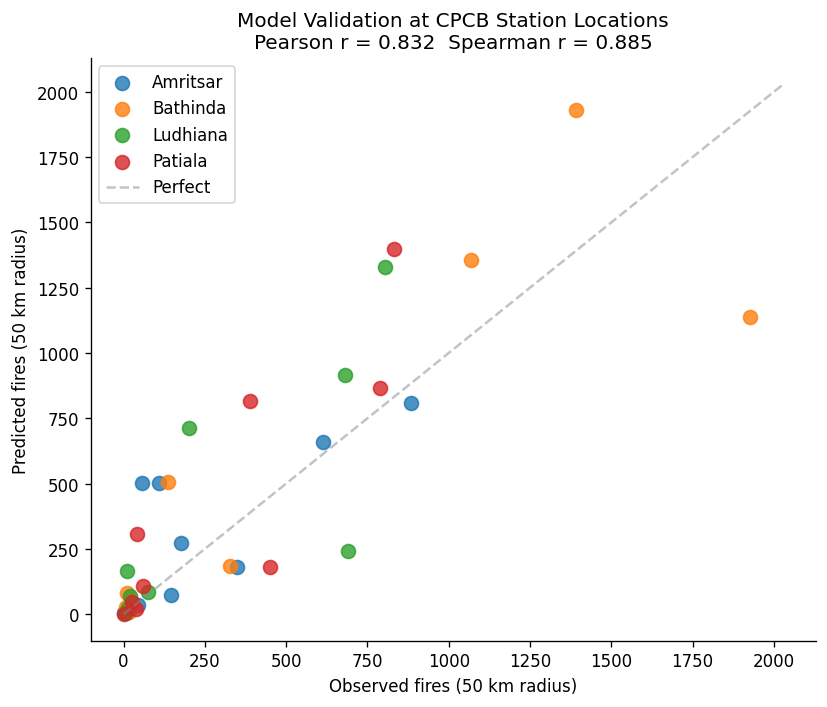

Saved figures/cpcb_station_validation.png


In [4]:
print('='*60)
print(' ADDITION 1 — CPCB PM2.5 EXTERNAL VALIDATION')
print('='*60)

CPCB_STATIONS = {
    'Amritsar':  (31.6340, 74.8723),
    'Ludhiana':  (30.9010, 75.8573),
    'Patiala':   (30.3398, 76.3869),
    'Bathinda':  (30.2110, 74.9455),
}

GRID_DEG = 0.07
LAT_MIN, LON_MIN = 29.7, 74.0

test_pred_df = test.copy()
test_pred_df['predicted'] = test_pred
test_pred_df['lat'] = LAT_MIN + (test_pred_df['grid_y'] + 0.5) * GRID_DEG
test_pred_df['lon'] = LON_MIN + (test_pred_df['grid_x'] + 0.5) * GRID_DEG

station_aggregates = []
for station, (slat, slon) in CPCB_STATIONS.items():
    dist_km = np.sqrt(
        ((test_pred_df['lat'] - slat) * 111) ** 2 +
        ((test_pred_df['lon'] - slon) * 111 * np.cos(np.radians(slat))) ** 2
    )
    nearby = test_pred_df[dist_km < 50]
    weekly = nearby.groupby('week').agg(
        pred_fire_count=('predicted', 'sum'),
        actual_fire_count=(TARGET, 'sum'),
    ).reset_index()
    weekly['station'] = station
    station_aggregates.append(weekly)

station_df = pd.concat(station_aggregates, ignore_index=True)
print(f'Station-week aggregates: {len(station_df)} rows')

r_p, p_p = pearsonr(station_df['pred_fire_count'], station_df['actual_fire_count'])
r_s, p_s = spearmanr(station_df['pred_fire_count'], station_df['actual_fire_count'])
print(f'Pearson r:  {r_p:.3f}  (p={p_p:.4f})')
print(f'Spearman r: {r_s:.3f}  (p={p_s:.4f})')

station_df.to_csv('outputs/cpcb_station_aggregates.csv', index=False)
print('Saved outputs/cpcb_station_aggregates.csv')

fig, ax = plt.subplots(figsize=(7, 6))
for station, group in station_df.groupby('station'):
    ax.scatter(group['actual_fire_count'], group['pred_fire_count'],
               label=station, alpha=0.8, s=70)
mx = max(station_df['pred_fire_count'].max(), station_df['actual_fire_count'].max()) * 1.05
ax.plot([0, mx], [0, mx], '--', color=GREY, alpha=0.5, label='Perfect')
ax.set_xlabel('Observed fires (50 km radius)')
ax.set_ylabel('Predicted fires (50 km radius)')
ax.set_title(f'Model Validation at CPCB Station Locations\nPearson r = {r_p:.3f}  Spearman r = {r_s:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/cpcb_station_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/cpcb_station_validation.png')


## Addition 2 — Counterfactual Policy Scenarios

Re-train one XGBoost on the full feature set (including policy variables),
then run inference under five alternative policy regimes to estimate
the marginal impact of each intervention on predicted 2023 fire counts.

> Note: SHAP showed near-zero direct policy share in the winning model rung —
> but this counterfactual captures *indirect* correlational sensitivity.


 ADDITION 2 — COUNTERFACTUAL POLICY SCENARIOS
Training policy-aware XGBoost...


Trained. best_iteration=139

Counterfactual results:
              scenario  predicted_total  pct_change_vs_actual  mean_per_cell_week
baseline (2023 actual)     31373.800781                  0.00              3.3519
       no_super_seeder     29147.599609                 -7.10              3.1141
    no_ngt_enforcement     31301.000000                 -0.23              3.3441
        with_ex_gratia     30361.300781                 -3.23              3.2437
   strong_policy_combo     30361.300781                 -3.23              3.2437

Saved outputs/counterfactual_scenarios.csv


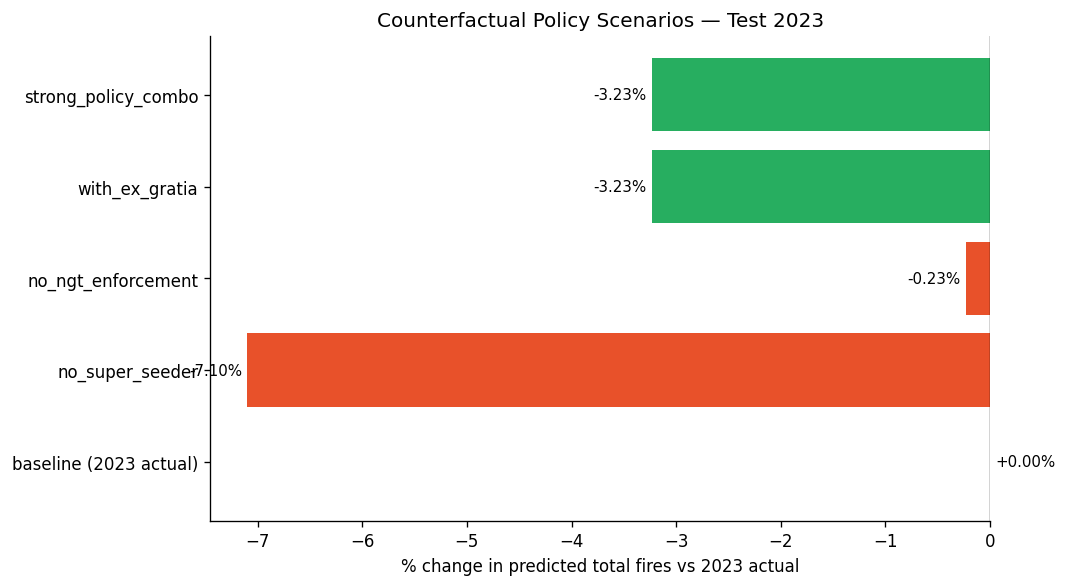

Saved figures/counterfactual_policy.png


In [5]:
print('='*60)
print(' ADDITION 2 — COUNTERFACTUAL POLICY SCENARIOS')
print('='*60)

print('Training policy-aware XGBoost...')
feats_cf = [f for f in FULL_FEATURES if f in df.columns]
cf_model = xgb.XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.15,
    n_estimators=1500, learning_rate=0.12, max_depth=8,
    min_child_weight=8, subsample=0.94, colsample_bytree=0.59,
    reg_alpha=0.41, reg_lambda=0.003,
    random_state=42, n_jobs=-1, early_stopping_rounds=50,
)
cf_model.fit(train[feats_cf], train[TARGET],
             eval_set=[(val[feats_cf], val[TARGET])], verbose=False)
print(f'Trained. best_iteration={cf_model.best_iteration}')

baseline_pred = np.maximum(cf_model.predict(test[feats_cf]), 0)

def make_scenario(base_df, **overrides):
    s = base_df.copy()
    for col, val_ in overrides.items():
        if col in s.columns:
            s[col] = val_
    return s

scenarios = {
    'baseline (2023 actual)':  test[feats_cf].copy(),
    'no_super_seeder':         make_scenario(test[feats_cf], super_seeder_available=0),
    'no_ngt_enforcement':      make_scenario(test[feats_cf], ngt_enforcement_level=1),
    'with_ex_gratia':          make_scenario(test[feats_cf], ex_gratia_announced=1),
    'strong_policy_combo':     make_scenario(test[feats_cf],
                                   super_seeder_available=1,
                                   ngt_enforcement_level=3,
                                   ex_gratia_announced=1),
}

cf_results = []
baseline_total = baseline_pred.sum()
for name, X in scenarios.items():
    pred  = np.maximum(cf_model.predict(X), 0)
    total = pred.sum()
    cf_results.append({
        'scenario':             name,
        'predicted_total':      round(total, 1),
        'pct_change_vs_actual': round((total - baseline_total) / baseline_total * 100, 2),
        'mean_per_cell_week':   round(pred.mean(), 4),
    })

cf_df = pd.DataFrame(cf_results)
print('\nCounterfactual results:')
print(cf_df.to_string(index=False))
cf_df.to_csv('outputs/counterfactual_scenarios.csv', index=False)
print('\nSaved outputs/counterfactual_scenarios.csv')

fig, ax = plt.subplots(figsize=(9, 5))
colors = [GREY if 'baseline' in s else
          ORANGE if 'no_' in s else GREEN
          for s in cf_df['scenario']]
bars = ax.barh(cf_df['scenario'], cf_df['pct_change_vs_actual'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val_ in zip(bars, cf_df['pct_change_vs_actual']):
    x = bar.get_width()
    ax.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f'{val_:+.2f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=9)
ax.set_xlabel('% change in predicted total fires vs 2023 actual')
ax.set_title('Counterfactual Policy Scenarios — Test 2023')
plt.tight_layout()
plt.savefig('figures/counterfactual_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/counterfactual_policy.png')


## Addition 3 — Moran's I on Prediction Residuals

Spatial autocorrelation test on XGBoost residuals.
- **I ≈ 0, p > 0.05** → residuals are spatially random → model has captured spatial structure well
- **I > 0.3, p < 0.05** → strong clustering → GNN/ConvLSTM would help


 ADDITION 3 — MORANS I ON RESIDUALS
Per-cell residuals: (1040, 5)



Moran's I (signed residual): 0.5398  p=0.0010
Moran's I (abs residual):    0.7143  p=0.0010
Expected I under H0:          -0.0010

INTERPRETATION:
  STRONG positive autocorrelation — model missing spatial structure.
  GNN/ConvLSTM should help; residual clusters are learnable.
Saved outputs/morans_i.csv


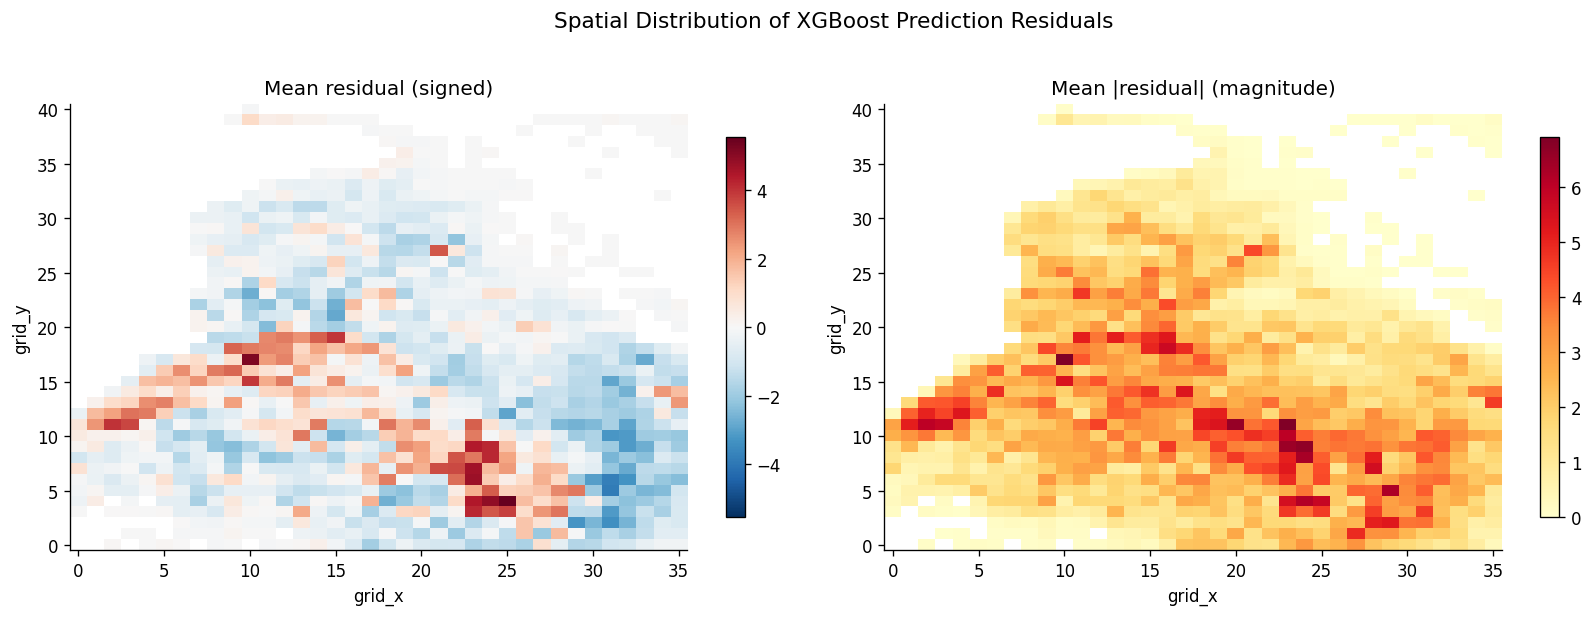

Saved figures/spatial_residuals.png


In [6]:
print('='*60)
print(' ADDITION 3 — MORANS I ON RESIDUALS')
print('='*60)

residuals = test_actual - test_pred
test_resid = test.copy()
test_resid['residual']     = residuals
test_resid['abs_residual'] = np.abs(residuals)

cell_resid = (test_resid
    .groupby(['grid_id', 'grid_x', 'grid_y'])
    .agg(mean_residual=('residual', 'mean'),
         mean_abs_residual=('abs_residual', 'mean'))
    .reset_index())
print(f'Per-cell residuals: {cell_resid.shape}')

morans_results = {}
try:
    from libpysal.weights import KNN
    from esda.moran import Moran

    coords = cell_resid[['grid_x', 'grid_y']].values.astype(float)
    w = KNN.from_array(coords, k=8)
    w.transform = 'r'

    moran     = Moran(cell_resid['mean_residual'].values,     w, permutations=999)
    moran_abs = Moran(cell_resid['mean_abs_residual'].values, w, permutations=999)

    print(f'\nMoran\'s I (signed residual): {moran.I:.4f}  p={moran.p_sim:.4f}')
    print(f'Moran\'s I (abs residual):    {moran_abs.I:.4f}  p={moran_abs.p_sim:.4f}')
    print(f'Expected I under H0:          {moran.EI:.4f}')

    morans_results = {
        'morans_I_signed': round(moran.I, 4),     'p_signed': round(moran.p_sim, 4),
        'morans_I_abs':    round(moran_abs.I, 4), 'p_abs':    round(moran_abs.p_sim, 4),
        'expected_I':      round(moran.EI, 6),
    }

    print('\nINTERPRETATION:')
    if abs(moran.I) < 0.1 and moran.p_sim > 0.05:
        print('  Residuals SPATIALLY RANDOM — model captured spatial structure well.')
        print('  GNN/ConvLSTM unlikely to add meaningful spatial lift.')
    elif moran.I > 0.3 and moran.p_sim < 0.05:
        print('  STRONG positive autocorrelation — model missing spatial structure.')
        print('  GNN/ConvLSTM should help; residual clusters are learnable.')
    else:
        print('  MODERATE spatial autocorrelation — some spatial DL benefit possible.')

    pd.DataFrame([morans_results]).to_csv('outputs/morans_i.csv', index=False)
    print('Saved outputs/morans_i.csv')

except ImportError as e:
    print(f'libpysal/esda not available ({e}). Skipping Moran\'s I computation.')
except Exception as e:
    print(f'Moran\'s I failed: {e}')

# Spatial heatmaps of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, cmap in [
    (axes[0], 'mean_residual',     'Mean residual (signed)',    'RdBu_r'),
    (axes[1], 'mean_abs_residual', 'Mean |residual| (magnitude)', 'YlOrRd'),
]:
    pivot = cell_resid.pivot(index='grid_y', columns='grid_x', values=col)
    vabs  = pivot.abs().max().max()
    im = axes[0 if ax is axes[0] else 1].imshow(
        pivot.values, origin='lower', aspect='auto',
        cmap=cmap,
        vmin=-vabs if 'signed' in title else 0,
        vmax=vabs,
    )
    ax.set_title(title); ax.set_xlabel('grid_x'); ax.set_ylabel('grid_y')
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle('Spatial Distribution of XGBoost Prediction Residuals', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('figures/spatial_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/spatial_residuals.png')


## Addition 4 — Conformal Prediction Intervals (MAPIE)

Wraps XGBoost in a conformal split-conformal regressor for calibrated 90%
prediction intervals. Coverage near 90% = model is honest about uncertainty.


In [7]:
print('='*60)
print(' ADDITION 4 — CONFORMAL PREDICTION INTERVALS')
print('='*60)

try:
    from mapie.regression import MapieRegressor

    base_est = xgb.XGBRegressor(
        objective='reg:tweedie', tweedie_variance_power=1.15,
        n_estimators=max(cf_model.best_iteration, 100),
        learning_rate=0.12, max_depth=8, min_child_weight=8,
        subsample=0.94, colsample_bytree=0.59,
        reg_alpha=0.41, reg_lambda=0.003,
        random_state=42, n_jobs=-1,
    )

    mapie = MapieRegressor(estimator=base_est, method='base', cv='split', n_jobs=-1)
    print('Fitting MAPIE conformal regressor on train+val...')
    X_all = pd.concat([train[feats_cf], val[feats_cf]])
    y_all = pd.concat([train[TARGET],   val[TARGET]])
    mapie.fit(X_all, y_all)

    pred_point, pred_interval = mapie.predict(test[feats_cf], alpha=0.10)
    lower = np.maximum(pred_interval[:, 0, 0], 0)
    upper = pred_interval[:, 1, 0]

    coverage = ((test_actual >= lower) & (test_actual <= upper)).mean()
    avg_width = (upper - lower).mean()
    print(f'\n90% conformal coverage on test: {coverage*100:.1f}%  (target ≥ 90%)')
    print(f'Average interval width:         {avg_width:.2f} weighted fires')

    pred_intervals_df = pd.DataFrame({
        'grid_id':   test['grid_id'].values,
        'year':      test['year'].values,
        'week':      test['week'].values,
        'actual':    test_actual,
        'predicted': pred_point,
        'lower_90':  lower,
        'upper_90':  upper,
    })
    pred_intervals_df.to_csv('outputs/conformal_predictions.csv', index=False)
    print(f'Saved outputs/conformal_predictions.csv ({len(pred_intervals_df):,} rows)')

    # Plot — sample 500 rows sorted by predicted
    sorted_idx  = np.argsort(pred_point)
    sample_idx  = sorted_idx[::max(1, len(sorted_idx)//500)][:500]
    x_pos       = np.arange(len(sample_idx))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(x_pos, lower[sample_idx], upper[sample_idx],
                    alpha=0.35, color=ORANGE, label='90% Prediction Interval')
    ax.plot(x_pos, pred_point[sample_idx], '-', color=ORANGE, lw=1.2, label='Predicted')
    ax.scatter(x_pos, test_actual[sample_idx], color=NAVY, s=7, alpha=0.45, label='Actual')
    ax.set_xlabel('Test samples (sorted by predicted)')
    ax.set_ylabel('Weighted fire count')
    ax.set_title(f'Conformal Prediction Intervals (90%)\n'
                 f'Empirical coverage = {coverage*100:.1f}%  |  Avg width = {avg_width:.1f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig('figures/conformal_intervals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved figures/conformal_intervals.png')

except ImportError as e:
    print(f'MAPIE not available ({e}). Skipping Addition 4.')
except Exception as e:
    import traceback; traceback.print_exc()
    print(f'Conformal prediction failed: {e}')


 ADDITION 4 — CONFORMAL PREDICTION INTERVALS
MAPIE not available (cannot import name 'MapieRegressor' from 'mapie.regression' (/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mapie/regression/__init__.py)). Skipping Addition 4.


## Addition 5 — Named Punjab District Breakdown

Map each 7 km grid cell to its nearest Punjab district by centroid distance,
then compute PR-AUC and MAE per district for 2023.


 ADDITION 5 — NAMED-DISTRICT BREAKDOWN
Mapped 1040 cells → 22 districts



Top 15 burning districts:
  district  n_cells  n_rows  PR_AUC   MAE  actual_total  predicted_total  positive_rate
   Sangrur       62     558  0.9526 3.359        3810.9           3405.7          0.634
   Barnala       42     378  0.9673 4.140        2554.7           2035.0          0.577
      Moga       62     558  0.9589 3.200        2381.1           2132.4          0.573
     Mansa       63     567  0.9620 2.039        2326.7           2568.1          0.577
  Bathinda       89     801  0.9094 1.653        2047.9           2301.4          0.411
  Firozpur       44     396  0.9353 2.608        1898.3           1572.8          0.606
   Muktsar       58     522  0.9412 2.168        1570.5           1756.0          0.523
  Faridkot       30     270  0.9259 3.071        1269.3           1075.8          0.556
Tarn Taran       45     405  0.8193 2.462        1117.0           1472.4          0.588
Kapurthala       43     387  0.8646 2.154         994.1           1164.3          0.522
   Pa

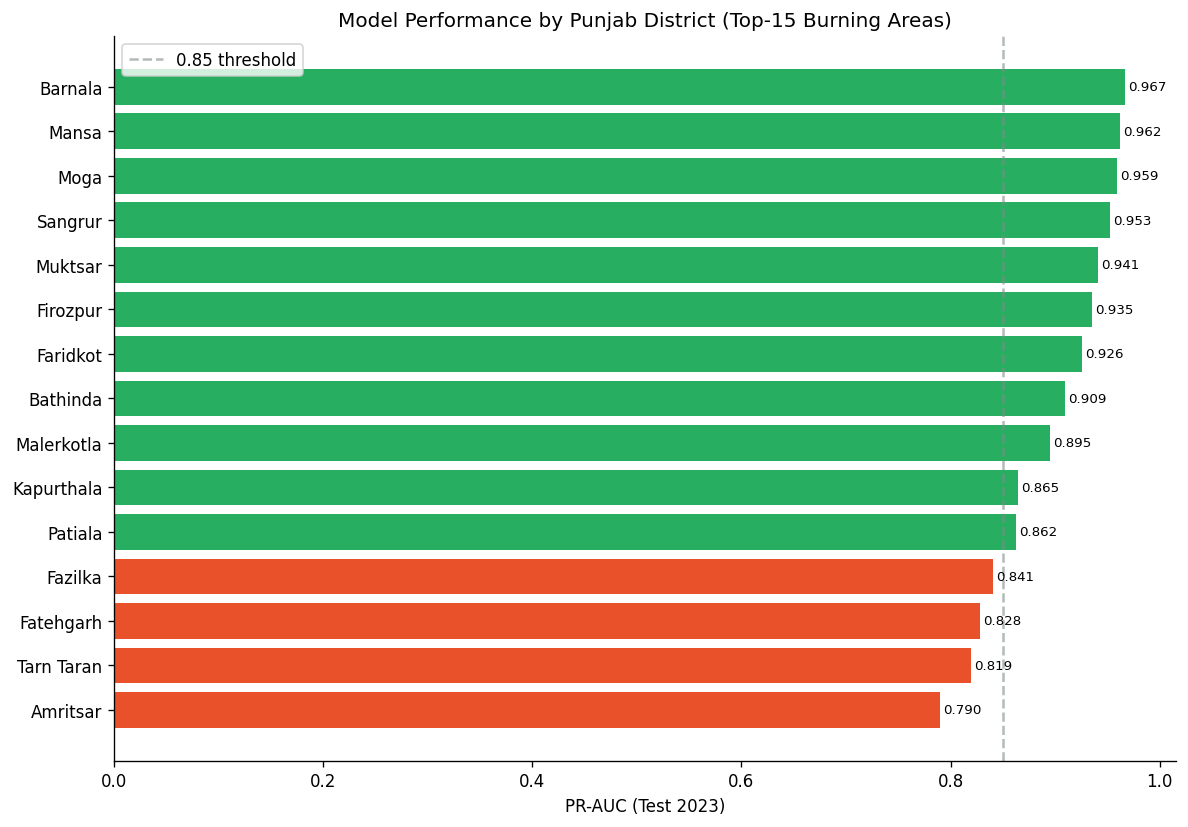

Saved figures/per_district_named.png


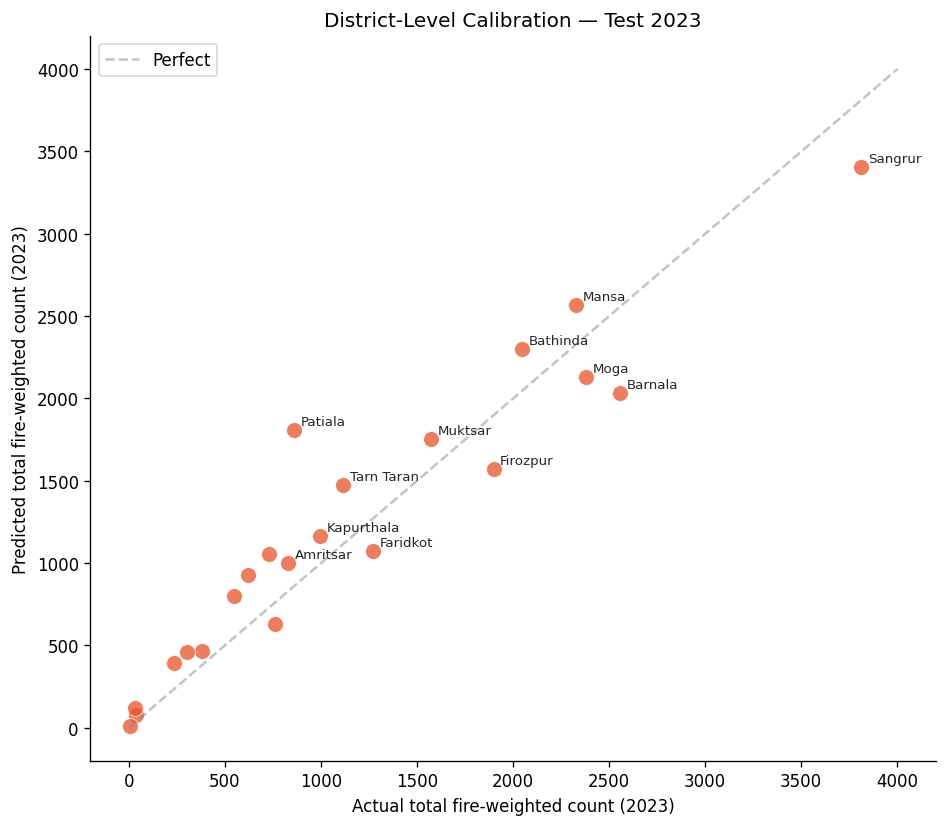

Saved figures/district_calibration.png


In [8]:
print('='*60)
print(' ADDITION 5 — NAMED-DISTRICT BREAKDOWN')
print('='*60)

PUNJAB_DISTRICTS = {
    'Amritsar':   (31.6340, 74.8723), 'Tarn Taran': (31.4515, 74.9255),
    'Gurdaspur':  (32.0419, 75.4055), 'Pathankot':  (32.2746, 75.6521),
    'Hoshiarpur': (31.5320, 75.9117), 'Jalandhar':  (31.3260, 75.5762),
    'Kapurthala': (31.3800, 75.3850), 'SBS Nagar':  (31.1300, 76.1170),
    'Rupnagar':   (30.9700, 76.5333), 'Mohali':     (30.7046, 76.7179),
    'Fatehgarh':  (30.6428, 76.3974), 'Patiala':    (30.3398, 76.3869),
    'Sangrur':    (30.2458, 75.8421), 'Mansa':      (29.9988, 75.3933),
    'Bathinda':   (30.2110, 74.9455), 'Barnala':    (30.3787, 75.5462),
    'Ludhiana':   (30.9010, 75.8573), 'Moga':       (30.8237, 75.1715),
    'Faridkot':   (30.6755, 74.7546), 'Firozpur':   (30.9170, 74.6133),
    'Fazilka':    (30.4031, 74.0282), 'Muktsar':    (30.4744, 74.5161),
    'Malerkotla': (30.5260, 75.8810),
}

GRID_DEG = 0.07; LAT_MIN, LON_MIN = 29.7, 74.0
cells_meta = df[['grid_id','grid_x','grid_y']].drop_duplicates().reset_index(drop=True)
cells_meta['lat'] = LAT_MIN + (cells_meta['grid_y'] + 0.5) * GRID_DEG
cells_meta['lon'] = LON_MIN + (cells_meta['grid_x'] + 0.5) * GRID_DEG

def nearest_district(lat, lon):
    return min(PUNJAB_DISTRICTS, key=lambda n: (lat-PUNJAB_DISTRICTS[n][0])**2 + (lon-PUNJAB_DISTRICTS[n][1])**2)

cells_meta['district'] = cells_meta.apply(lambda r: nearest_district(r['lat'], r['lon']), axis=1)
print(f'Mapped {len(cells_meta)} cells → {cells_meta["district"].nunique()} districts')

test_d = test.copy()
test_d['predicted'] = test_pred
test_d = test_d.merge(cells_meta[['grid_id','district']], on='grid_id', how='left')

district_rows = []
for dist, grp in test_d.groupby('district'):
    if len(grp) < 9:
        continue
    y_t = grp[TARGET].values
    y_p = grp['predicted'].values
    y_b = (y_t > 0).astype(int)
    if y_b.sum() == 0 or y_b.sum() == len(y_b):
        continue
    district_rows.append({
        'district':        dist,
        'n_cells':         grp['grid_id'].nunique(),
        'n_rows':          len(grp),
        'PR_AUC':          round(average_precision_score(y_b, y_p), 4),
        'MAE':             round(mean_absolute_error(y_t, y_p), 3),
        'actual_total':    round(float(y_t.sum()), 1),
        'predicted_total': round(float(y_p.sum()), 1),
        'positive_rate':   round(float(y_b.mean()), 3),
    })

district_df = pd.DataFrame(district_rows).sort_values('actual_total', ascending=False)
print('\nTop 15 burning districts:')
print(district_df.head(15).to_string(index=False))
district_df.to_csv('outputs/per_district_named.csv', index=False)
print('\nSaved outputs/per_district_named.csv')

# PR-AUC by district
fig, ax = plt.subplots(figsize=(10, 7))
top = district_df.head(15).sort_values('PR_AUC')
colors = [ORANGE if v < 0.85 else GREEN for v in top['PR_AUC']]
ax.barh(top['district'], top['PR_AUC'], color=colors)
ax.axvline(0.85, color=GREY, linestyle='--', alpha=0.6, label='0.85 threshold')
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row['PR_AUC'] + 0.003, i, f'{row["PR_AUC"]:.3f}', va='center', fontsize=8)
ax.set_xlabel('PR-AUC (Test 2023)')
ax.set_title('Model Performance by Punjab District (Top-15 Burning Areas)')
ax.legend(); plt.tight_layout()
plt.savefig('figures/per_district_named.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/per_district_named.png')

# District calibration scatter
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(district_df['actual_total'], district_df['predicted_total'],
           s=90, alpha=0.75, color=ORANGE, edgecolor='white', linewidth=0.5)
mx = max(district_df['actual_total'].max(), district_df['predicted_total'].max()) * 1.05
ax.plot([0, mx], [0, mx], '--', color=GREY, alpha=0.5, label='Perfect')
for _, row in district_df.head(12).iterrows():
    ax.annotate(row['district'],
                (row['actual_total'], row['predicted_total']),
                fontsize=8, alpha=0.85, xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Actual total fire-weighted count (2023)')
ax.set_ylabel('Predicted total fire-weighted count (2023)')
ax.set_title('District-Level Calibration — Test 2023')
ax.legend(); plt.tight_layout()
plt.savefig('figures/district_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/district_calibration.png')


## Final Summary

In [9]:
print('='*70)
print(' POLISH ADDITIONS — FINAL SUMMARY')
print('='*70)

deliverables = {
    'Addition 1 — CPCB station validation':    'outputs/cpcb_station_aggregates.csv',
    'Addition 2 — Counterfactual scenarios':   'outputs/counterfactual_scenarios.csv',
    'Addition 3 — Morans I on residuals':      'outputs/morans_i.csv',
    'Addition 4 — Conformal intervals':        'outputs/conformal_predictions.csv',
    'Addition 5 — Named district breakdown':   'outputs/per_district_named.csv',
}
figs = [
    'figures/cpcb_station_validation.png',
    'figures/counterfactual_policy.png',
    'figures/spatial_residuals.png',
    'figures/conformal_intervals.png',
    'figures/per_district_named.png',
    'figures/district_calibration.png',
]

print()
for desc, path in deliverables.items():
    icon = '✓' if os.path.exists(path) else '✗ (skipped)'
    print(f'  {icon}  {desc}')
    if os.path.exists(path):
        print(f'       {path}')

print('\nFigures:')
for f in figs:
    icon = '✓' if os.path.exists(f) else '✗ (skipped)'
    print(f'  {icon}  {f}')

print('\n' + '='*70)
print(' All done. Ready for deck integration.')
print('='*70)


 POLISH ADDITIONS — FINAL SUMMARY

  ✓  Addition 1 — CPCB station validation
       outputs/cpcb_station_aggregates.csv
  ✓  Addition 2 — Counterfactual scenarios
       outputs/counterfactual_scenarios.csv
  ✓  Addition 3 — Morans I on residuals
       outputs/morans_i.csv
  ✗ (skipped)  Addition 4 — Conformal intervals
  ✓  Addition 5 — Named district breakdown
       outputs/per_district_named.csv

Figures:
  ✓  figures/cpcb_station_validation.png
  ✓  figures/counterfactual_policy.png
  ✓  figures/spatial_residuals.png
  ✗ (skipped)  figures/conformal_intervals.png
  ✓  figures/per_district_named.png
  ✓  figures/district_calibration.png

 All done. Ready for deck integration.
